In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [7]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')
# text svg

'notebook'

# Decode phoneme and articulator

In [56]:
from scipy.ndimage import gaussian_filter1d

ref = 'bipolar'

task = 'PhonemeSequence'
decode_type = 'token'

result_path = BIDSPath(
    datatype=f'(decode)(resolved){decode_type}',
    root= f'../results/{task}(roi)({ref})',
    suffix='highgamma',
    check=False
)

full_path = result_path.match()

scores = []

for path in full_path:
    mat = h5py.File(path, 'r')
    # accuracy: (time, fold)
    accuracy = mat['accuracy'][()]
    # time: (time,)
    time = mat['time'][()]
    # p_value: (time,)
    p_value = mat['p_values'][()]
    # baseline: (time, fold, n_perm)
    baseline = mat['baseline'][()]
    mat.close()

    n_time, n_fold = accuracy.shape

    # ---- 1) baseline 在 perm 维度上平均 → (time, fold) ----
    baseline_mean = baseline.mean(axis=-1)  # shape: (time, fold)

    # ---- 2) 宽表：每列一个 fold（accuracy）----
    sigma = 2  # 单位：time 采样点数（不是秒）；你可以调 1~5 之类
    accuracy = gaussian_filter1d(accuracy, sigma=sigma, axis=0, mode="nearest")
    df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
    df_acc = df_acc.rename(columns={'index': 'time'})

    # 宽表 baseline
    df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
    df_base = df_base.rename(columns={'index': 'time'})

    # ---- 3) 宽 → 长，显式保留 fold ----
    df_acc = df_acc.melt(
        id_vars='time',
        var_name='fold',
        value_name='accuracy'
    )  # (time * fold, 3)

    df_base = df_base.melt(
        id_vars='time',
        var_name='fold',
        value_name='baseline'
    )

    # 合并 accuracy 和 baseline（按 time, fold 对齐）
    df = df_acc.merge(df_base, on=['time', 'fold'], how='left')

    # ---- 4) p_value 只有 time 维度，就按 time merge ----
    df_p = pd.DataFrame({'time': time, 'p_value': p_value})
    df = df.merge(df_p, on='time', how='left')

    # ---- 5) 加上 path 的元信息 ----
    hemi = 'Left' if path.subject[-1]=='l' else 'Right'
    roi = path.subject[:-1]
    df['roi'] = roi
    df['phase'] = path.processing
    df['hemi'] = hemi
    df['description'] = path.description
    df['phoneme'] = path.recording
    df['datatype'] = path.datatype.replace('(decode)(resolving)', '')
    df['band'] = path.suffix

    scores.append(df)

scores = pd.concat(scores, ignore_index=True)
# scores = scores[scores.roi.isin(['INS','STG','SMC'])]
# rename
scores = scores[scores.description=='Repeat']
# scores = scores[scores.phoneme=='image']
scores.head()

,time,fold,accuracy,baseline,p_value,roi,phase,hemi,description,phoneme,datatype,band
0,-0.30,0,0.585051,0.522381,0.447761,AIC,Go,Left,Repeat,None,(decode)(resolved)token,highgamma
1,-0.28,0,0.554919,0.534524,0.776119,AIC,Go,Left,Repeat,None,(decode)(resolved)token,highgamma
2,-0.26,0,0.537175,0.544048,0.990050,AIC,Go,Left,Repeat,None,(decode)(resolved)token,highgamma
3,-0.24,0,0.534800,0.528571,0.746269,AIC,Go,Left,Repeat,None,(decode)(resolved)token,highgamma
4,-0.22,0,0.541866,0.535238,0.079602,AIC,Go,Left,Repeat,None,(decode)(resolved)token,highgamma


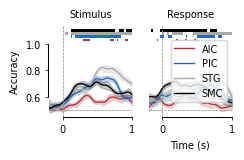

In [58]:
hue_order = ['AIC', 'PIC', 'STG','SMC']
hemis = ['Left']
phases = ['Stimulus','Response']

fig, axes = plt.subplots(1, len(phases), figsize=(3*len(phases)*cm, 3*len(hemis)*cm))

time_arr = scores['time'].unique()
time_arr.sort()

ymax, pad, bar_h = 1, 0.02, 0.02
chance = 1/2
ymin = 0.45

colors = [red, blue, 'darkgray','black']

for j, phase in enumerate(phases):
    ax = axes[j]
    
    legend = True if j == 1 else False
    
    subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]
    sns.lineplot(
        data=subset,
        x='time', y='accuracy', hue='roi',
        palette=colors, hue_order=hue_order,
        lw=1,
        ax=ax, legend=legend
    )
    
    # significant cluster（每个 roi 一个 bar）
    for k, roi in enumerate(hue_order):
        roi_data = subset[(subset.roi == roi) & (subset.fold == 0)].sort_values('time')
        if roi_data.empty:
            continue
        mask = (roi_data['p_value'].values < 0.05)
        offset = k * (bar_h + 0.005)
        
        if mask.any():
            ax.fill_between(
                roi_data['time'].values,
                ymax + pad + offset,
                ymax + pad + bar_h + offset,
                where=mask,
                color=colors[k],
                alpha=1,
                step='mid',
                linewidth=0
            )

for j, phase in enumerate(phases):
    ax = axes[j]
    ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
    ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
    ax.set_xlim(-0.2, 1)
    ax.set_ylim(ymin, ymax + pad + len(hue_order)*(bar_h + 0.005) + 0.02)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # 右列去掉 y 轴
    if j == 1:
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
    
    # 顶行加标题
    ax.set_title(phase.capitalize(), fontsize=7)
    
    # 左列加 hemi 标签
    if j == 0:
        ax.set_ylabel('Accuracy', fontsize=7)

axes[1].set_xlabel('Time (s)', fontsize=7)
axes[1].legend(fontsize=7)

for ax in fig.axes:
    sns.despine(ax=ax, trim=True, offset=0.2)

# remove y spine for rightmost axes
for ax in axes[1:].flatten():
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_ylabel('')

# plt.tight_layout()
fig.savefig(f'../img/fig3/fig3_{task}_{decode_type}.svg', dpi=300, bbox_inches='tight')
plt.show()

In [59]:
# load HGA data
task ='PhonemeSequence'
ref = 'bipolar'
hga_paths = BIDSPath(
            root=f'../results/{task}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)
coords = HGAs.drop(columns=['time', 'value']).drop_duplicates()
HGAs.head()

100%|██████████| 135/135 [00:03<00:00, 35.68it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0019_ROG13-14,-0.043502,False,mOccG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_occipital_middle,41.472074,-88.150203,-3.545099
1,-1.0,D0019_RIIH5-6,-0.054793,False,OPC,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_Pole_occipital,11.886836,-94.046488,10.403848
2,-1.0,D0019_ROG4-5,-0.025007,False,sOccG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_occipital_sup,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG18-19,-0.083139,False,Intersection,R,D0019,Repeat,PhonemeSequence,Audio,sound,Intersection,41.531682,-78.171196,19.605156
4,-1.0,D0019_RLSO7-8,-0.040828,False,PhG,R,D0019,Repeat,PhonemeSequence,Audio,sound,ctx_rh_G_oc-temp_med-Parahip,18.457267,-10.274114,-31.949923


In [60]:
# load decoding channels
PHONEME_PATH = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/derivatives'

phase = 'Response'

decoding_pts = BIDSPath(
    root=os.path.join(PHONEME_PATH, 'decoding(bipolar)'),
    processing=phase,
    extension='.h5',
    check=False,
)

pick_coord = []

for roi in hue_order:
    roi_pt = decoding_pts.update(subject=f'{roi}l').match()[0]
    with h5py.File(roi_pt, 'r') as f:
        ch = [c.decode() for c in f['channel'][:]]
        
        df = coords.copy()[coords.channel.isin(ch)]
        df['roi'] = roi
        pick_coord.append(df)
        
pick_coord = pd.concat(pick_coord)
pick_coord.head()

,channel,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
7,D0052_LI5-6,False,AIC,L,D0052,Repeat,PhonemeSequence,Audio,sound,ctx_lh_S_circular_insula_sup,-35.562153,3.638421,9.06771
3277,D0052_LI5-6,True,AIC,L,D0052,Repeat,PhonemeSequence,Audio,sound,ctx_lh_S_circular_insula_sup,-35.562153,3.638421,9.06771
10,D0052_LI5-6,False,AIC,L,D0052,Repeat,PhonemeSequence,Go,sound,ctx_lh_S_circular_insula_sup,-35.562153,3.638421,9.06771
3002,D0052_LI5-6,True,AIC,L,D0052,Repeat,PhonemeSequence,Go,sound,ctx_lh_S_circular_insula_sup,-35.562153,3.638421,9.06771
10,D0052_LI5-6,False,AIC,L,D0052,Repeat,PhonemeSequence,Response,sound,ctx_lh_S_circular_insula_sup,-35.562153,3.638421,9.06771


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 11:33:25.775 (4804.241s) [    7F448708A440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x5b48af0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 11:33:25.878 (4804.344s) [    7F448708A440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x5b48af0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: eg

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot


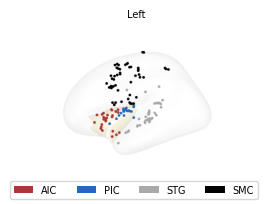

In [61]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree


# ROI 颜色：和 decoding 图保持一致
roi_colors = dict(zip(hue_order, colors))

# 只画左半球电极
pick_coord_lh = pick_coord[pick_coord["hemi"].isin(["L", "lh", "Left"])].copy()
if pick_coord_lh.empty:
    pick_coord_lh = pick_coord[pick_coord["x"] < 0].copy()

cord = pick_coord_lh[["x", "y", "z"]].values
rois = pick_coord_lh["roi"].values

# 加载左半球表面：pial -> inflated（把电极贴到 inflated 上）
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

_, lh_indices = lh_tree.query(cord)
cord_on_infl = lh_coords_infl[lh_indices]

# 创建 inflated 左脑
lh_brain = Brain(
    "fsaverage",
    subjects_dir=recon_dir,
    surf="inflated",
    hemi="lh",
    background="white",
    show=False,
    cortex=(0.95, 0.95, 0.95),
    alpha=0.1,
    size=(600 * cm, 600 * cm),
)

labels = mne.read_labels_from_annot(
    "fsaverage",
    parc="aparc.a2009s",
    hemi="lh",
    subjects_dir=recon_dir,
)
insula_labels = [lab for lab in labels if "insul" in lab.name.lower()]
for lab in insula_labels:
    lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)

# 统一大小，不做大小调整
point_size = 25

# 按 ROI 上色
for roi in hue_order:
    roi_mask = rois == roi
    if not roi_mask.any():
        continue

    cloud = pv.PolyData(cord_on_infl[roi_mask])
    lh_brain._renderer.plotter.add_mesh(
        cloud,
        render_points_as_spheres=True,
        point_size=point_size,
        color=roi_colors[roi],
        lighting=False,
        smooth_shading=False,
        opacity=1,
    )

lh_brain.show_view(view="lateral", distance=400)
lh_brain._renderer.plotter.window_size = [1400, 1400]

fig, ax = plt.subplots(1, 1, figsize=(5 * cm, 5 * cm))
ax.imshow(lh_brain.screenshot(mode="rgb"))
ax.axis("off")
ax.set_title("Left", fontsize=7)

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=roi_colors[roi], label=roi) for roi in hue_order]
fig.legend(handles=legend_elements, loc="lower center", ncol=len(hue_order), fontsize=7)

lh_brain.close()
fig.savefig(f'../img/fig3/fig3_{task}_spatial.svg', dpi=300, bbox_inches='tight')
plt.show()

# Decoding lexicality

In [62]:
# load HGA data
task ='LexicalDelay'
ref = 'bipolar'
hga_paths = BIDSPath(
            root=f'../results/{task}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)
coords = HGAs.drop(columns=['time', 'value']).drop_duplicates()
HGAs.head()

100%|██████████| 320/320 [00:34<00:00,  9.22it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0023_RPIF3-4,0.249398,False,Intersection,R,D0023,Decision,LexicalDelay,Audio,sound,Intersection,41.901912,-28.228735,17.149502
1,-1.0,D0023_R2MF2-3,0.051112,False,Intersection,R,D0023,Decision,LexicalDelay,Audio,sound,Intersection,11.195341,-7.769187,33.884895
2,-1.0,D0023_RPSF1-2,0.095070,False,CGs,R,D0023,Decision,LexicalDelay,Audio,sound,ctx_rh_S_pericallosal,6.423360,-15.496811,23.453189
3,-1.0,D0023_RPIF1-2,0.231350,False,Sylvian,R,D0023,Decision,LexicalDelay,Audio,sound,ctx_rh_Lat_Fis-post,35.187262,-26.860379,15.945394
4,-1.0,D0023_RPIF2-3,0.361105,False,Sylvian,R,D0023,Decision,LexicalDelay,Audio,sound,ctx_rh_Lat_Fis-post,38.280793,-27.303607,16.525972


In [81]:
ref = 'bipolar'

task = 'LexicalDelay'
decode_type = 'lexicality'

result_path = BIDSPath(
    datatype=f'(decode)(resolved){decode_type}',
    root= f'../results/{task}(roi)({ref})',
    suffix='highgamma',
    check=False
)

full_path = result_path.match()

scores = []

for path in full_path:
    mat = h5py.File(path, 'r')
    # accuracy: (time, fold)
    accuracy = mat['accuracy'][()]
    # time: (time,)
    time = mat['time'][()]
    # p_value: (time,)
    p_value = mat['p_values'][()]
    # baseline: (time, fold, n_perm)
    baseline = mat['baseline'][()]
    
    mat.close()

    n_time, n_fold = accuracy.shape

    # ---- 1) baseline 在 perm 维度上平均 → (time, fold) ----
    baseline_mean = baseline.mean(axis=-1)  # shape: (time, fold)

    # ---- 2) 宽表：每列一个 fold（accuracy）----
    sigma = 2  # 单位：time 采样点数（不是秒）；你可以调 1~5 之类
    accuracy = gaussian_filter1d(accuracy, sigma=sigma, axis=0, mode="nearest")
    df_acc = pd.DataFrame(accuracy, index=time, columns=range(n_fold)).reset_index()
    df_acc = df_acc.rename(columns={'index': 'time'})

    # 宽表 baseline
    df_base = pd.DataFrame(baseline_mean, index=time, columns=range(n_fold)).reset_index()
    df_base = df_base.rename(columns={'index': 'time'})

    # ---- 3) 宽 → 长，显式保留 fold ----
    df_acc = df_acc.melt(
        id_vars='time',
        var_name='fold',
        value_name='accuracy'
    )  # (time * fold, 3)

    df_base = df_base.melt(
        id_vars='time',
        var_name='fold',
        value_name='baseline'
    )

    # 合并 accuracy 和 baseline（按 time, fold 对齐）
    df = df_acc.merge(df_base, on=['time', 'fold'], how='left')

    # ---- 4) p_value 只有 time 维度，就按 time merge ----
    df_p = pd.DataFrame({'time': time, 'p_value': p_value})
    df = df.merge(df_p, on='time', how='left')

    # ---- 5) 加上 path 的元信息 ----
    hemi = 'Left' if path.subject[-1]=='l' else 'Right'
    roi = path.subject[:-1]
    df['roi'] = roi
    df['phase'] = path.processing
    df['hemi'] = hemi
    df['description'] = path.description
    df['phoneme'] = path.recording
    df['datatype'] = path.datatype.replace('(decode)(resolving)', '')
    df['band'] = path.suffix

    scores.append(df)

scores = pd.concat(scores, ignore_index=True)
# scores = scores[scores.roi.isin(['INS','STG','SMC'])]
# rename
scores = scores[scores.description=='Repeat']
# scores = scores[scores.phoneme=='image']
scores.head()

,time,fold,accuracy,baseline,p_value,roi,phase,hemi,description,phoneme,datatype,band
0,-0.30,0,0.462525,0.492941,0.497512,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
1,-0.28,0,0.482471,0.515882,0.164179,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
2,-0.26,0,0.498030,0.491765,0.233831,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
3,-0.24,0,0.507448,0.492941,0.253731,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma
4,-0.22,0,0.507795,0.488824,0.995025,AIC,Delay,Left,Repeat,None,(decode)(resolved)lexicality,highgamma


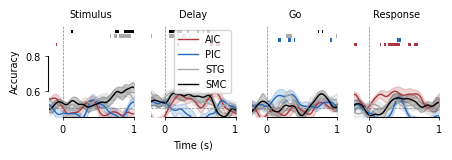

In [86]:
hue_order = ['AIC', 'PIC', 'STG','SMC']
# roi_colors = dict(zip(hue_order, [insula_color, smc_color, stg_color]))

hemis = ['Left']
phases = ['Stimulus','Delay','Go','Response']

fig, axes = plt.subplots(1, len(phases), figsize=(3.2*len(phases)*cm, 3*len(hemis)*cm))

time_arr = scores['time'].unique()
time_arr.sort()

ymax, pad, bar_h = 0.85, 0.01, 0.02
chance = 1/2
ymin = 0.45

colors = [red, blue, 'darkgray','black']

for j, phase in enumerate(phases):
    ax = axes[j]
    
    legend = True if j == 1 else False
    
    subset = scores[(scores.phase == phase) & (scores.hemi == hemi)]
    sns.lineplot(
        data=subset,
        x='time', y='accuracy', hue='roi',
        palette=colors, hue_order=hue_order,
        lw=1,
        ax=ax, legend=legend
    )
    
    # significant cluster（每个 roi 一个 bar）
    for k, roi in enumerate(hue_order):
        roi_data = subset[(subset.roi == roi) & (subset.fold == 0)].sort_values('time')
        if roi_data.empty:
            continue
        mask = (roi_data['p_value'].values < 0.05)
        offset = k * (bar_h + 0.005)
        
        if mask.any():
            ax.fill_between(
                roi_data['time'].values,
                ymax + pad + offset,
                ymax + pad + bar_h + offset,
                where=mask,
                color=colors[k],
                alpha=1,
                step='mid',
                linewidth=0
            )

for j, phase in enumerate(phases):
    ax = axes[j]
    ax.tick_params(labelsize=7, width=0.5, length=2)
    plt.setp(ax.spines.values(), linewidth=0.75)
    ax.axvline(x=0, color='gray', linestyle='--', lw=0.5)
    ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
    ax.set_xlim(-0.2, 1)
    ax.set_ylim(ymin, ymax + pad + len(hue_order)*(bar_h + 0.005) + 0.02)
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    # 右列去掉 y 轴
    if j == 1:
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
    
    # 顶行加标题
    ax.set_title(phase.capitalize(), fontsize=7)
    
    # 左列加 hemi 标签
    if j == 0:
        ax.set_ylabel('Accuracy', fontsize=7)

axes[1].set_xlabel('Time (s)', fontsize=7)
axes[1].legend(fontsize=7)

for ax in fig.axes:
    sns.despine(ax=ax, trim=True, offset=0.2)

# remove y spine for rightmost axes
for ax in axes[1:].flatten():
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.set_ylabel('')
    
fig.savefig(f'../img/fig3/fig3_time_decode_{task}_{ref}.svg', dpi=300, bbox_inches='tight')
plt.show()

In [88]:
# load decoding channels
LEXICAL_PATH = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/derivatives'

phase = 'Response'

decoding_pts = BIDSPath(
    root=os.path.join(LEXICAL_PATH, 'decoding(bipolar)'),
    processing=phase,
    extension='.h5',
    check=False,
)

pick_coord = []

for roi in hue_order:
    roi_pt = decoding_pts.update(subject=f'{roi}l').match()[0]
    with h5py.File(roi_pt, 'r') as f:
        ch = [c.decode() for c in f['channel'][:]]
        
        df = coords.copy()[coords.channel.isin(ch)]
        df['roi'] = roi
        pick_coord.append(df)
        
pick_coord = pd.concat(pick_coord)
pick_coord.head()

,channel,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
16,D0047_LI5-6,False,AIC,L,D0047,Decision,LexicalDelay,Audio,sound,ctx_lh_S_circular_insula_sup,-37.102721,5.539169,3.773575
2816,D0047_LI5-6,True,AIC,L,D0047,Decision,LexicalDelay,Audio,sound,ctx_lh_S_circular_insula_sup,-37.102721,5.539169,3.773575
16,D0047_LI5-6,False,AIC,L,D0047,Repeat,LexicalDelay,Audio,sound,ctx_lh_S_circular_insula_sup,-37.102721,5.539169,3.773575
2752,D0047_LI5-6,True,AIC,L,D0047,Repeat,LexicalDelay,Audio,sound,ctx_lh_S_circular_insula_sup,-37.102721,5.539169,3.773575
16,D0047_LI5-6,False,AIC,L,D0047,Decision,LexicalDelay,Delay,sound,ctx_lh_S_circular_insula_sup,-37.102721,5.539169,3.773575


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 13:17:56.109 (11074.575s) [    7F448708A440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1d18fa90): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-03 13:17:56.181 (11074.646s) [    7F448708A440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1d18fa90): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/fsaverage/label/lh.aparc.a2009s.annot


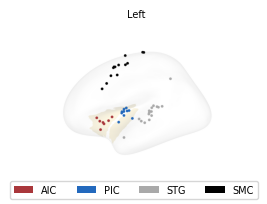

In [90]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from mne.viz import Brain
from scipy.spatial import cKDTree


# ROI 颜色：和 decoding 图保持一致
roi_colors = dict(zip(hue_order, colors))

# 只画左半球电极
pick_coord_lh = pick_coord[pick_coord["hemi"].isin(["L", "lh", "Left"])].copy()
if pick_coord_lh.empty:
    pick_coord_lh = pick_coord[pick_coord["x"] < 0].copy()

cord = pick_coord_lh[["x", "y", "z"]].values
rois = pick_coord_lh["roi"].values

# 加载左半球表面：pial -> inflated（把电极贴到 inflated 上）
lh_pial_path = f"{recon_dir}/fsaverage/surf/lh.pial"
lh_infl_path = f"{recon_dir}/fsaverage/surf/lh.inflated"
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
lh_coords_infl, _ = mne.read_surface(lh_infl_path)
lh_tree = cKDTree(lh_coords_pial)

_, lh_indices = lh_tree.query(cord)
cord_on_infl = lh_coords_infl[lh_indices]

# 创建 inflated 左脑
lh_brain = Brain(
    "fsaverage",
    subjects_dir=recon_dir,
    surf="inflated",
    hemi="lh",
    background="white",
    show=False,
    cortex=(0.95, 0.95, 0.95),
    alpha=0.1,
    size=(600 * cm, 600 * cm),
)

labels = mne.read_labels_from_annot(
    "fsaverage",
    parc="aparc.a2009s",
    hemi="lh",
    subjects_dir=recon_dir,
)
insula_labels = [lab for lab in labels if "insul" in lab.name.lower()]
for lab in insula_labels:
    lh_brain.add_label(lab, borders=False, color=insula_color, alpha=0.4)

# 统一大小，不做大小调整
point_size = 25

# 按 ROI 上色
for roi in hue_order:
    roi_mask = rois == roi
    if not roi_mask.any():
        continue

    cloud = pv.PolyData(cord_on_infl[roi_mask])
    lh_brain._renderer.plotter.add_mesh(
        cloud,
        render_points_as_spheres=True,
        point_size=point_size,
        color=roi_colors[roi],
        lighting=False,
        smooth_shading=False,
        opacity=1,
    )

lh_brain.show_view(view="lateral", distance=400)
lh_brain._renderer.plotter.window_size = [1400, 1400]

fig, ax = plt.subplots(1, 1, figsize=(5 * cm, 5 * cm))
ax.imshow(lh_brain.screenshot(mode="rgb"))
ax.axis("off")
ax.set_title("Left", fontsize=7)

from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=roi_colors[roi], label=roi) for roi in hue_order]
fig.legend(handles=legend_elements, loc="lower center", ncol=len(hue_order), fontsize=7)

lh_brain.close()
fig.savefig(f'../img/fig3/fig3_{task}_spatial.svg', dpi=300, bbox_inches='tight')
plt.show()